[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cafzal/frontier/blob/feat/progressive-certify/examples/progressive_solving_value.ipynb)

# Progressive solving: does explore-then-certify pay off, and where does cuOpt help?

**The real flow.** Frontier explores with NSGA (heuristic) and certifies with an exact solver. Two ways
to produce the exact overlay:
- **exact alone** — `optimize(solver=…)`: a full exact pass, the exact inner solver on **every** NSGA
  evaluation (~pop×gen solves), a separate search from the exploratory run.
- **progressive certify** — `optimizer.certify_curated(problem, nsga_run, solver=…)`: exact-solve **only
  the NSGA run's frontier points** (~dozens). The heuristic explores; the exact solver certifies only
  what it kept. *(Added to the engine for this study — `tests/test_certify_curated.py` — so the notebook
  reflects a real Frontier capability, not a hand-rolled one.)*

**Three configs**, on a **QP** (`investment_portfolio`), an **LP** (`production_mix`), and a discrete
binary **MILP** (`capital_project_selection`) — all scaled from the
real bundles (combinatorial group-limits + >2 objectives), each in **HiGHS (CPU)** and **cuOpt (GPU)**:

| Config | Exact work |
|---|---|
| **approx only** | none (NSGA heuristic frontier) |
| **approx + progressive certify** | exact-solve the ~dozens of curated points |
| **exact alone** | full exact pass (~pop×gen solves) |

**Four metrics:** **adaptability** (which problem shapes each engine even fits — NSGA is universal, exact
is gated) · then, on the shapes exact fits, swept over scale n: **optimality** (% of points the exact
reference doesn't dominate) · **coverage** (hypervolume share vs the exact reference) · **speed**. For
speed, the NSGA *explore* is a shared cost (you run it either way), so the honest comparison is the
**exact cost** — progressive certify vs a full exact pass — which is where cuOpt-vs-HiGHS lives.

**Fair A/B:** same machine; same seed ⇒ identical NSGA; exact reference = non-dominated union of every
exact-backed frontier; we report what the numbers show.

In [1]:
import subprocess
try:
    out = subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total,driver_version", "--format=csv,noheader"],
                         capture_output=True, text=True)
    print(out.stdout.strip() or "no nvidia-smi output")
except FileNotFoundError:
    print("No NVIDIA GPU — cuOpt configs skipped; HiGHS/CPU + approx run fully. "
          "In Colab: Runtime -> Change runtime type -> GPU (T4).")

Tesla T4, 15360 MiB, 580.82.07


In [2]:
# Bootstrap (Colab): clone Frontier + install cuOpt + HiGHS + deps. ~2-3 min first run.
import os, subprocess, sys
REPO = "/content/frontier"
if os.path.isdir("/content"):
    if not os.path.isdir(REPO):
        subprocess.run(["git", "clone", "-q", "-b", "feat/progressive-certify",
                        "https://github.com/cafzal/frontier.git", REPO],
                       env={**os.environ, "GIT_TERMINAL_PROMPT": "0"}, check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "--extra-index-url", "https://pypi.nvidia.com", "cuopt-cu12"], check=False)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "highspy",
                    "scipy>=1.11", "pandas>=2.0", "matplotlib>=3.7", "pydantic>=2.0", "pymoo>=0.6"], check=True)
    if REPO not in sys.path: sys.path.insert(0, REPO)
else:
    d = os.getcwd()
    for _ in range(5):
        if os.path.isfile(os.path.join(d, "solvers", "__init__.py")):
            if d not in sys.path: sys.path.insert(0, d)
            break
        d = os.path.dirname(d)
print("ok")

ok


In [3]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pymoo.indicators.hv import HV
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

from engine import optimizer as _opt
from engine.optimizer import optimize, certify_curated          # <-- the real progressive-certify path
from engine.problem_io import examples_dir, read_bundle, from_portable
import solvers.cuopt_backend as cb

try:
    import cuopt.linear_programming  # noqa: F401
    HAS_CUOPT = True
except Exception as e:
    HAS_CUOPT = False
    print(f"cuOpt not importable ({type(e).__name__}) — GPU configs skipped.")

SMOKE = bool(os.environ.get("LP_SCALE_SMOKE"))
QP_NS = [40, 80] if SMOKE else [60, 150, 300, 500]      # asset counts for the QP scale sweep
LP_NS = [30, 60] if SMOKE else [40, 120, 250, 400]      # product counts for the LP scale sweep
CAP_NS = [30, 60] if SMOKE else [30, 60, 120]           # project counts for the binary MILP sweep (heavier)
print(f"machine: {os.cpu_count()} CPUs | GPU: {'yes' if HAS_CUOPT else 'no'} | smoke={SMOKE}")

machine: 2 CPUs | GPU: yes | smoke=False


In [4]:
# ===================== Scale up the REAL bundles (QP + LP) =====================
_QP_TMPL = read_bundle(examples_dir() / "investment_portfolio")
_RET = [s.value for s in _QP_TMPL.scores if s.objective == "Return"]
_YLD = [s.value for s in _QP_TMPL.scores if s.objective == "Yield"]
_QP_GMAX = next(c.max for c in _QP_TMPL.constraints if c.type == "group_limit")
_QP_GSIZE = int(round(np.mean([len(c.options) for c in _QP_TMPL.constraints if c.type == "group_limit"])))

def scale_qp(n, seed=7, n_factors=10):
    rng = np.random.default_rng(seed)
    B = rng.standard_normal((n, n_factors)) * rng.uniform(0.04, 0.22, (1, n_factors))
    cov = B @ B.T + np.diag(rng.uniform(0.01, 0.09, n)); cov *= 280.0 / np.mean(np.diag(cov)); cov = cb._nearest_psd(cov)
    ret = np.array([_RET[i % len(_RET)] for i in range(n)]) * rng.uniform(0.9, 1.1, n)
    yld = np.array([_YLD[i % len(_YLD)] for i in range(n)]) * rng.uniform(0.9, 1.1, n)
    vol = np.sqrt(np.diag(cov)); names = [f"Asset {i+1:04d}" for i in range(n)]
    scores = ([{"option": names[i], "objective": "Return", "value": round(float(ret[i]), 3)} for i in range(n)]
              + [{"option": names[i], "objective": "Volatility", "value": round(float(vol[i]), 3)} for i in range(n)]
              + [{"option": names[i], "objective": "Yield", "value": round(float(yld[i]), 3)} for i in range(n)])
    entries = {names[i]: {names[j]: round(float(cov[i, j]), 6) for j in range(n)} for i in range(n)}
    cons = [{"type": "max_allocation", "max": 30}]
    for s in range(0, n, _QP_GSIZE):
        grp = names[s:s + _QP_GSIZE]
        if len(grp) > _QP_GMAX: cons.append({"type": "group_limit", "options": grp, "max": _QP_GMAX})
    problem = {"name": f"Portfolio (n={n})", "domain": "finance", "context": _QP_TMPL.context,
               "approach": "proportional", "objectives": [o.model_dump() for o in _QP_TMPL.objectives], "constraints": cons}
    return from_portable(problem, {"options": [{"name": nm, "description": ""} for nm in names], "scores": scores,
                                   "interaction_matrices": [{"objective": "Volatility", "entries": entries}]})

_LP_TMPL = read_bundle(examples_dir() / "production_mix")
_LP_ARCH = [[float(next(s.value for s in _LP_TMPL.scores if s.option == o.name and s.objective == ob.name))
             for ob in _LP_TMPL.objectives] for o in _LP_TMPL.options]
_LP_OBJ = [o.name for o in _LP_TMPL.objectives]
_LP_GMAX = next(c.max for c in _LP_TMPL.constraints if c.type == "group_limit")
_LP_GSIZE = int(round(np.mean([len(c.options) for c in _LP_TMPL.constraints if c.type == "group_limit"])))

def scale_lp(n, seed=11):
    rng = np.random.default_rng(seed)
    names = [f"{_LP_TMPL.options[i % len(_LP_TMPL.options)].name} #{i//len(_LP_TMPL.options)+1}" for i in range(n)]
    scores = []
    for i in range(n):
        arch = _LP_ARCH[i % len(_LP_ARCH)]
        for j, ob in enumerate(_LP_OBJ):
            scores.append({"option": names[i], "objective": ob, "value": round(arch[j] * float(rng.uniform(0.9, 1.1)), 3)})
    cap = next((c.max for c in _LP_TMPL.constraints if c.type == "max_allocation"), 30)
    cons = [{"type": "max_allocation", "max": cap}]
    for s in range(0, n, _LP_GSIZE):
        grp = names[s:s + _LP_GSIZE]
        if len(grp) > _LP_GMAX: cons.append({"type": "group_limit", "options": grp, "max": _LP_GMAX})
    problem = {"name": f"Production Mix (n={n})", "domain": "manufacturing", "context": _LP_TMPL.context,
               "approach": "proportional", "objectives": [o.model_dump() for o in _LP_TMPL.objectives], "constraints": cons}
    return from_portable(problem, {"options": [{"name": nm, "description": ""} for nm in names], "scores": scores})

# Binary MILP — scale the committed capital_project_selection_120 structure (its category archetypes +
# budget / cardinality / dependency / exclusion / group constraints) proportionally to n projects. 4
# additive objectives → an exact MILP; the inner solve here is a real 0/1 MILP (heavy), not a tiny LP.
_MIX = {"Growth": 30, "Digital": 20, "R&D": 20, "Maintenance": 20, "Compliance": 15, "Efficiency": 15}
_TILT = {"Growth": 1.25, "Digital": 1.15, "R&D": 1.4, "Maintenance": 0.5, "Compliance": 0.2, "Efficiency": 0.9}
_RISK = {"Growth": 55, "Digital": 45, "R&D": 78, "Maintenance": 22, "Compliance": 18, "Efficiency": 35}
_FIT = {"Growth": 70, "Digital": 72, "R&D": 60, "Maintenance": 45, "Compliance": 85, "Efficiency": 58}

def scale_capital(n, seed=11):
    rng = np.random.default_rng(seed)
    counts = {c: max(1, round(n * k / 120)) for c, k in _MIX.items()}
    cats = [c for c, k in counts.items() for _ in range(k)]
    n = len(cats); ids = [f"P{i+1:05d}" for i in range(n)]
    options, scores, cost_arr = [], [], []
    for pid, cat in zip(ids, cats):
        cost = float(np.round(rng.uniform(4, 45), 1))
        npv = float(np.round(max(-8, cost * _TILT[cat] * rng.uniform(0.6, 1.7) - rng.uniform(0, 10)), 1))
        risk = float(np.round(np.clip(_RISK[cat] + rng.normal(0, 12), 5, 98), 1))
        fit = float(np.round(np.clip(_FIT[cat] + rng.normal(0, 14), 10, 99), 1))
        cost_arr.append(cost); options.append({"name": pid, "description": f"{cat} initiative"})
        scores += [{"option": pid, "objective": "NPV", "value": npv}, {"option": pid, "objective": "Cost", "value": cost},
                   {"option": pid, "objective": "Risk", "value": risk}, {"option": pid, "objective": "StrategicFit", "value": fit}]
    by_cat = {c: [ids[i] for i in range(n) if cats[i] == c] for c in counts}
    budget = float(np.round(0.22 * sum(cost_arr), -1))
    forced = by_cat["Compliance"][:max(1, round(3 * n / 120))]; enablers = by_cat["Efficiency"]
    dep_src = by_cat["Growth"][:round(6 * n / 120)] + by_cat["Digital"][:round(4 * n / 120)]
    deps = [{"type": "dependency", "if_option": s, "then_option": enablers[i % len(enablers)]} for i, s in enumerate(dep_src)]
    gp, rp = by_cat["Growth"], by_cat["R&D"]; npair = min(len(gp) // 2, len(rp) // 2, max(1, round(5 * n / 120)))
    excl = ([{"type": "exclusion_pair", "option_a": gp[2 * i], "option_b": gp[2 * i + 1]} for i in range(npair)]
            + [{"type": "exclusion_pair", "option_a": rp[2 * i], "option_b": rp[2 * i + 1]} for i in range(npair)])
    groups = [{"type": "group_limit", "options": by_cat[c], "max": max(1, round(m * n / 120))}
              for c, m in {"Growth": 8, "Digital": 6, "R&D": 6, "Maintenance": 7}.items()]
    card_lo, card_hi = max(2, round(0.15 * n)), max(3, round(0.33 * n))
    cons = ([{"type": "objective_bound", "objective": "Cost", "operator": "max", "value": budget},
             {"type": "cardinality", "min": card_lo, "max": card_hi}]
            + [{"type": "force_include", "option": f} for f in forced] + deps + excl + groups)
    problem = {"name": f"Capital Projects (n={n})", "domain": "corporate finance",
               "context": f"Select capital projects under a ${budget:.0f}M budget.", "approach": "binary",
               "objectives": [{"name": "NPV", "direction": "maximize", "unit": "$M", "aggregation": "sum"},
                              {"name": "Cost", "direction": "minimize", "unit": "$M", "aggregation": "sum"},
                              {"name": "Risk", "direction": "minimize", "unit": "score", "aggregation": "sum"},
                              {"name": "StrategicFit", "direction": "maximize", "unit": "score", "aggregation": "sum"}],
               "constraints": cons}
    return from_portable(problem, {"options": options, "scores": scores})

print("scale_qp / scale_lp / scale_capital ready (real bundles; combinatorial; >2 objectives)")

scale_qp / scale_lp / scale_capital ready (real bundles; combinatorial; >2 objectives)


In [5]:
# ===================== Metrics + the five configs (real flow) =====================
def dirs_of(p): return np.array([1.0 if o.direction.value == "minimize" else -1.0 for o in p.objectives])
def _pts(run, objs): return np.array([[s.objective_values[o.name] for o in objs] for s in run.solutions])

def assemble_exact(sets_natural, dirs):
    allpts = np.vstack([np.asarray(p, float) * dirs for p in sets_natural if len(p)])
    return allpts[NonDominatedSorting().do(allpts, only_non_dominated_front=True)]

def box(sets_natural, ref_min, dirs):
    allmin = np.vstack([np.asarray(p, float) * dirs for p in sets_natural if len(p)] + [ref_min])
    lo, hi = allmin.min(0), allmin.max(0)
    return lo, np.where(hi > lo, hi - lo, 1.0), np.full(ref_min.shape[1], 1.1)

def optimality(pts_nat, ref_min, dirs, eps=1e-9):
    if not len(pts_nat): return 0.0
    P = np.asarray(pts_nat, float) * dirs
    return float(sum(not np.any(np.all(ref_min <= p + eps, axis=1) & np.any(ref_min < p - eps, axis=1)) for p in P) / len(P))

def coverage(pts_nat, ref_min, lo, span, refpt, dirs):
    if not len(pts_nat): return 0.0
    hv = HV(ref_point=refpt)
    return float(hv((np.asarray(pts_nat, float) * dirs - lo) / span) / hv((ref_min - lo) / span))

def run_configs(problem):
    '''Run the configs on one scaled problem; return per-config (total runtime, exact-cost, optimality,
    coverage). exact-cost = the work to certify/exactify (progressive certify time, or the full exact
    pass) — the NSGA explore is shared, so this is the honest speed comparison.'''
    objs = problem.objectives; dirs = dirs_of(problem)
    t = time.perf_counter(); nsga = optimize(problem, seed=42); t_nsga = time.perf_counter() - t
    rt = {"approx": t_nsga}; ex = {"approx": 0.0}; fr = {"approx": _pts(nsga, objs)}
    for solver, tag in [("highs", "HiGHS")] + ([("cuopt", "cuOpt")] if HAS_CUOPT else []):
        t = time.perf_counter(); ea = optimize(problem, seed=42, solver=solver); t_ea = time.perf_counter() - t
        rt[f"exact·{tag}"] = t_ea; ex[f"exact·{tag}"] = t_ea; fr[f"exact·{tag}"] = _pts(ea, objs)
        t = time.perf_counter(); cc = certify_curated(problem, nsga, solver=solver); t_cc = time.perf_counter() - t
        rt[f"progressive·{tag}"] = t_nsga + t_cc; ex[f"progressive·{tag}"] = t_cc; fr[f"progressive·{tag}"] = _pts(cc, objs)
    ref = assemble_exact([v for k, v in fr.items() if k != "approx"], dirs)
    lo, span, refpt = box(list(fr.values()), ref, dirs)
    return pd.DataFrame([{"config": c, "runtime_s": round(rt[c], 3), "exact_cost_s": round(ex[c], 3),
                          "optimality": round(optimality(p, ref, dirs), 3),
                          "coverage": round(coverage(p, ref, lo, span, refpt, dirs), 3), "points": len(p)}
                         for c, p in fr.items()])

def sweep(make, ns, label):
    frames = []
    for n in ns:
        df = run_configs(make(n)); df["n"] = n; frames.append(df)
        print(f"  {label} n={n}: " + " | ".join(f"{r.config} opt={r.optimality:.2f} cov={r.coverage:.2f} exact={r.exact_cost_s:.1f}s"
                                                 for r in df.itertuples()))
    return pd.concat(frames, ignore_index=True)

COLOR = {"approx": "gray", "progressive·HiGHS": "darkorange", "exact·HiGHS": "orange",
         "progressive·cuOpt": "royalblue", "exact·cuOpt": "deepskyblue"}
def plot_sweep(df, title):
    cfgs = [c for c in COLOR if c in set(df.config)]
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
    for cfg in cfgs:
        d = df[df.config == cfg].sort_values("n"); ls = "--" if cfg.startswith("exact") else "-"
        ax[0].plot(d.n, d.optimality, ls, marker="o", color=COLOR[cfg], label=cfg)
        ax[1].plot(d.n, d.coverage, ls, marker="o", color=COLOR[cfg], label=cfg)
        if cfg != "approx":
            ax[2].plot(d.n, d.exact_cost_s, ls, marker="o", color=COLOR[cfg], label=cfg)
    ax[0].set_title("optimality (↑)"); ax[1].set_title("coverage (↑)")
    ax[2].set_title("exact cost (↓) — certify vs full pass"); ax[2].set_yscale("log")
    for a in ax: a.set_xlabel("problem size n"); a.grid(alpha=0.3); a.legend(fontsize=7)
    fig.suptitle(title); plt.tight_layout(); plt.show()
print("run_configs / sweep / plot ready")

run_configs / sweep / plot ready


## Adaptability — NSGA fits every shape; exact fits only the gated ones

Before optimality/coverage/speed (which only apply where an exact solver fits), the first metric is
**reach**: NSGA (the explore engine) handles *any* shape; the exact backends fit a gated subset
(`solvers.exact_solver_fits`). This is why NSGA explores and exact is an opt-in certify layer — and why
progressive certify (which rides the NSGA frontier) inherits NSGA's universal reach for exploration.

In [6]:
from solvers import exact_solver_fits

def _mini(approach, aggs, dirs=None, matrix=False):
    dirs = dirs or ["maximize"] * len(aggs); names = ["A", "B", "C"]
    objs = [{"name": f"Obj{j}", "direction": dirs[j], "aggregation": aggs[j]} for j in range(len(aggs))]
    scores = [{"option": o, "objective": f"Obj{j}", "value": float(1 + j + i)}
              for i, o in enumerate(names) for j in range(len(aggs))]
    cons = [{"type": "max_allocation", "max": 50}] if approach == "proportional" else [{"type": "cardinality", "min": 1, "max": 2}]
    prob = {"name": "x", "domain": "d", "context": "c", "approach": approach, "objectives": objs, "constraints": cons}
    sc = {"options": [{"name": n} for n in names], "scores": scores}
    if matrix:
        q = next(f"Obj{j}" for j, a in enumerate(aggs) if a == "quadratic")
        sc["interaction_matrices"] = [{"objective": q, "entries": {a: {b: (1.0 if a == b else 0.1) for b in names} for a in names}}]
    return from_portable(prob, sc)

SHAPES = [("binary · sum (selection)", "binary", ["sum", "sum"], None, False),
          ("binary · avg", "binary", ["avg", "sum"], None, False),
          ("binary · min/max", "binary", ["min", "max"], None, False),
          ("proportional · linear (LP)", "proportional", ["sum", "avg"], None, False),
          ("proportional · mean-variance (QP)", "proportional", ["avg", "quadratic"], ["maximize", "minimize"], True),
          ("proportional · min/max", "proportional", ["min", "max"], None, False),
          ("proportional · maximize-quadratic", "proportional", ["avg", "quadratic"], ["maximize", "maximize"], True)]
rows = []
for name, ap, aggs, dirs, mat in SHAPES:
    fits, reason = exact_solver_fits(_mini(ap, aggs, dirs, mat))
    rows.append({"problem shape": name, "NSGA": "yes", "exact": "yes" if fits else "no",
                 "why exact declines": "" if fits else reason.split(";")[0][:64]})
dfshape = pd.DataFrame(rows); print(dfshape.to_string(index=False))
nfit = sum(r["exact"] == "yes" for r in rows)
print(f"\nAdaptability: NSGA fits {len(rows)}/{len(rows)} shapes; exact fits {nfit}/{len(rows)}.")
print("NSGA is the universal explore engine; exact (and cuOpt) is an opt-in certify layer on supported shapes.")

                    problem shape NSGA exact                                               why exact declines
         binary · sum (selection)  yes   yes                                                                 
                     binary · avg  yes    no               the exact MILP optimizes additive (sum) objectives
                 binary · min/max  yes    no               the exact MILP optimizes additive (sum) objectives
       proportional · linear (LP)  yes   yes                                                                 
proportional · mean-variance (QP)  yes   yes                                                                 
           proportional · min/max  yes    no the exact QP optimizes linear (sum/avg) and quadratic objectives
proportional · maximize-quadratic  yes    no the exact QP is a min-variance solver, so the quadratic objectiv

Adaptability: NSGA fits 7/7 shapes; exact fits 3/7.
NSGA is the universal explore engine; exact (and cuOpt) is an opt-i

## QP arm — `investment_portfolio` (dense-covariance inner solve) — at scale

  QP n=60: approx opt=0.46 cov=0.91 exact=0.0s | exact·HiGHS opt=0.86 cov=0.81 exact=5.5s | progressive·HiGHS opt=0.96 cov=0.98 exact=1.4s | exact·cuOpt opt=0.59 cov=0.71 exact=291.2s | progressive·cuOpt opt=0.96 cov=0.98 exact=77.4s
  QP n=150: approx opt=0.36 cov=0.93 exact=0.0s | exact·HiGHS opt=0.86 cov=0.85 exact=21.5s | progressive·HiGHS opt=0.95 cov=0.98 exact=7.9s | exact·cuOpt opt=0.69 cov=0.70 exact=381.0s | progressive·cuOpt opt=0.95 cov=0.98 exact=141.9s
  QP n=300: approx opt=0.43 cov=0.93 exact=0.0s | exact·HiGHS opt=0.89 cov=0.87 exact=71.6s | progressive·HiGHS opt=0.87 cov=0.98 exact=34.8s | exact·cuOpt opt=0.80 cov=0.75 exact=552.2s | progressive·cuOpt opt=0.87 cov=0.98 exact=314.4s
  QP n=500: approx opt=0.41 cov=0.94 exact=0.0s | exact·HiGHS opt=0.73 cov=0.84 exact=195.5s | progressive·HiGHS opt=0.95 cov=0.99 exact=115.5s | exact·cuOpt opt=0.59 cov=0.75 exact=737.4s | progressive·cuOpt opt=0.95 cov=0.99 exact=673.3s


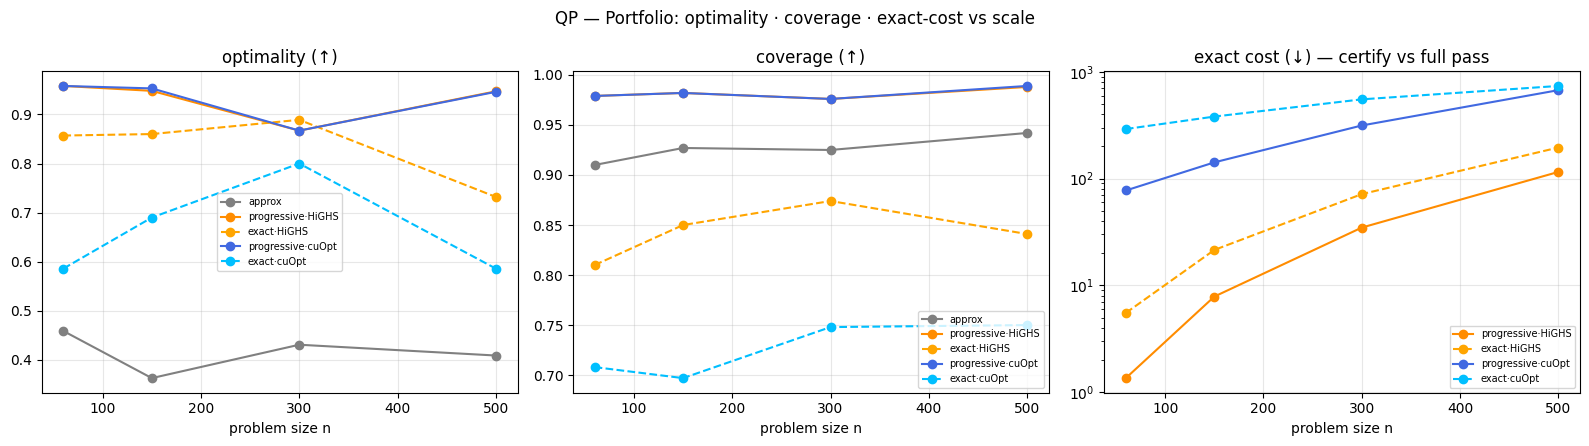

In [7]:
dfqp = sweep(scale_qp, QP_NS, "QP")
plot_sweep(dfqp, "QP — Portfolio: optimality · coverage · exact-cost vs scale")

## LP arm — `production_mix` (purely-linear inner solve) — at scale

  LP n=40: approx opt=0.69 cov=0.97 exact=0.0s | exact·HiGHS opt=0.98 cov=0.81 exact=2.5s | progressive·HiGHS opt=1.00 cov=0.98 exact=0.4s | exact·cuOpt opt=0.89 cov=0.81 exact=64.7s | progressive·cuOpt opt=1.00 cov=0.98 exact=28.6s
  LP n=120: approx opt=0.62 cov=0.98 exact=0.0s | exact·HiGHS opt=0.91 cov=0.88 exact=6.5s | progressive·HiGHS opt=0.99 cov=0.99 exact=1.6s | exact·cuOpt opt=0.86 cov=0.75 exact=77.8s | progressive·cuOpt opt=0.99 cov=0.99 exact=63.8s
  LP n=250: approx opt=0.52 cov=0.98 exact=0.0s | exact·HiGHS opt=0.93 cov=0.86 exact=13.1s | progressive·HiGHS opt=1.00 cov=1.00 exact=5.6s | exact·cuOpt opt=0.73 cov=0.81 exact=106.4s | progressive·cuOpt opt=1.00 cov=1.00 exact=134.8s
  LP n=400: approx opt=0.47 cov=0.98 exact=0.0s | exact·HiGHS opt=0.86 cov=0.91 exact=24.2s | progressive·HiGHS opt=0.99 cov=0.99 exact=10.4s | exact·cuOpt opt=0.89 cov=0.79 exact=136.6s | progressive·cuOpt opt=0.99 cov=0.99 exact=227.1s


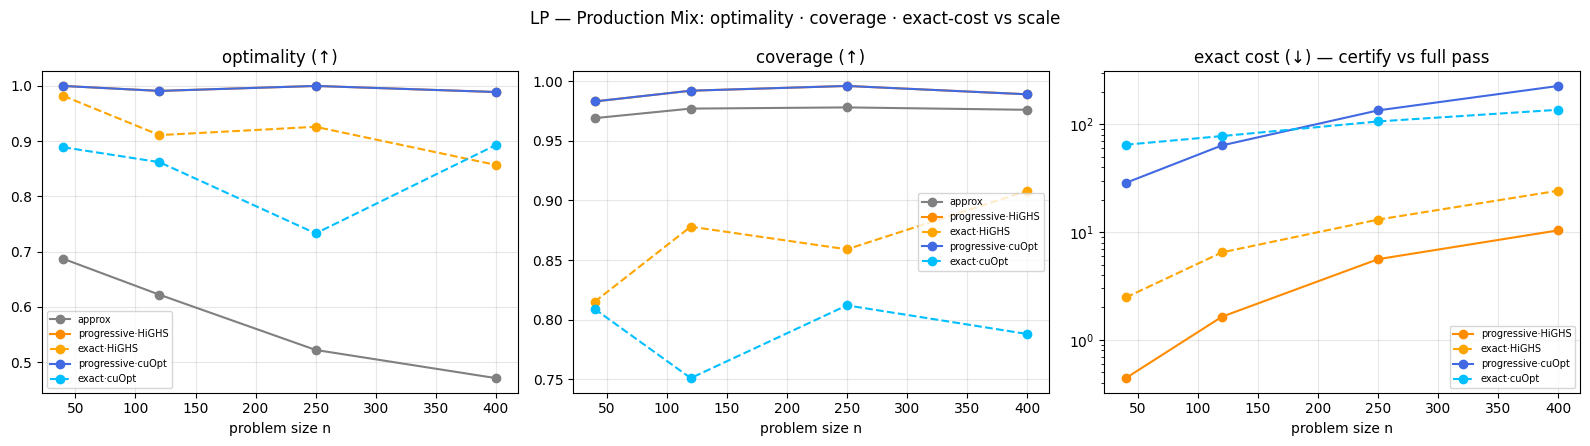

In [8]:
dflp = sweep(scale_lp, LP_NS, "LP")
plot_sweep(dflp, "LP — Production Mix: optimality · coverage · exact-cost vs scale")

## MILP arm — `capital_project_selection` (discrete 0/1 inner solve) — at scale

The discrete case: binary project selection under budget / cardinality / dependency / exclusion / group
constraints, 4 objectives. Here the inner solve is a real **0/1 MILP** (NP-hard, heavy) — so the full
exact pass (a MILP on every NSGA evaluation) is the *most* expensive of the three shapes, and progressive
certify (a MILP only per curated point) saves the most. It's also where cuOpt's GPU MILP has its
best shot at scale (the big-and-few regime). Binary MILP has no duals, so certify reports
frontier-derived shadow prices rather than solver duals — optimality/coverage/speed still apply.

In [ ]:
dfcap = sweep(scale_capital, CAP_NS, "MILP")
plot_sweep(dfcap, "MILP — Capital Projects: optimality · coverage · exact-cost vs scale")

  MILP n=30: approx opt=0.90 cov=0.93 exact=0.0s | exact·HiGHS opt=1.00 cov=0.68 exact=7.2s | progressive·HiGHS opt=1.00 cov=0.95 exact=1.0s | exact·cuOpt opt=1.00 cov=0.68 exact=182.8s | progressive·cuOpt opt=1.00 cov=0.95 exact=10.6s
  MILP n=60: approx opt=0.00 cov=0.60 exact=0.0s | exact·HiGHS opt=1.00 cov=0.80 exact=70.9s | progressive·HiGHS opt=1.00 cov=0.91 exact=14.3s | exact·cuOpt opt=1.00 cov=0.80 exact=550.3s | progressive·cuOpt opt=1.00 cov=0.91 exact=20.0s


## Verdict

Read the four metrics (this machine):

- **Adaptability** — NSGA fits *every* shape; the exact backends a gated subset. So NSGA is the universal
  explore engine and exact is an opt-in certify layer — progressive certify rides the NSGA frontier, so it
  keeps that universal reach for exploration while adding exact optimality where the shape qualifies.
- **Optimality** — approx is heuristic (many points the exact reference dominates); **progressive certify
  lifts it to exact-level** (each kept point is re-solved to optimality), matching exact-alone.
- **Coverage** — progressive keeps NSGA's broad frontier *and* sharpens it, so it holds coverage as well
  as or better than exact-alone (which runs a separate, smaller-budget exact search).
- **Speed (exact cost)** — the NSGA explore is shared, so the comparison that matters is the exact work to
  certify. **Progressive certify (~|frontier| solves) costs a fraction of a full exact pass (~pop×gen),
  and the gap widens with n** — most dramatically on the **MILP** (each inner solve is a heavy 0/1 MILP,
  so the full pass is the costliest of the three and progressive saves the most). **cuOpt** overtakes
  HiGHS on the heavy exact work — the dense-covariance **QP** at scale and the large **MILP** (big-and-few)
  — while the few-row **LP** gives the GPU little to gain.

**Takeaways:** (1) **progressive certify is the better explore-then-certify design** — exact-level
optimality on the broad NSGA frontier without a full second exact pass — now a real engine path
(`optimizer.certify_curated`); (2) **cuOpt earns its place on the heavy (QP) exact work at scale**, not
the light LP path. Both measured here, not assumed.